# Probe Classification Evaluation — Llama-3.2-3B

Tests each probe on exactly the distinction it was trained to make, on held-out
test plans, using **Llama-3.2-3B** (`meta-llama/Llama-3.2-3B-Instruct`).

Probe layers are read from `probe_manifest.json` produced by the training notebook.
The full layer sweep was performed across all 28 layers (0–27);
the best layer per probe is used here.

**Probe 1** uses `tp1_direction`: "Must Action A happen before Action B?"
- y=1: (a, b) is a real edge
- y=0: (a, b) is a reversed edge or an incomparable pair

**Probe 2** uses `tp2_necessity`: flexible-leading framing
- y=1 (keep): real edge
- y=0 (spurious): same-depth incomparable pair

**Drive setup:** place `dev.jsonl`, `test.jsonl`, `probe_manifest.json`,
and the two `.pkl` files in `DRIVE_DIR` before running.


**Drive setup:** before running, place these files in a single Google Drive
folder (default expected path: `MyDrive/dag-probing/`):

- `dev.jsonl`
- `test.jsonl`
- `probe_manifest.json`
- the two probe `.pkl` files named in the manifest

Update `DRIVE_DIR` in the setup cell if you use a different folder name or path.


In [10]:
from google.colab import drivedrive.mount('/content/drive')import osfrom huggingface_hub import loginlogin(token=os.getenv("HF_TOKEN", ""))import subprocess, shutilsubprocess.run(['pip','install','-q','transformers','accelerate',                'scikit-learn','tqdm','matplotlib'], check=True)import json as _jsonfrom pathlib import Path# ── Set this to the Drive folder containing your files ──────────────────────CONTENT   = Path('/content')DRIVE_DIR = CONTENTrequired_files = ['dev.jsonl', 'test.jsonl', 'probe_manifest.json']# Copy required files from Drive to local /content/ for faster repeated accessfor f in required_files:    src = DRIVE_DIR / f    dst = CONTENT / f    assert src.exists(), f'Missing in Drive: {src}'    if not dst.exists():        shutil.copy(src, dst)        print(f'  Copied {f} from Drive')    else:        print(f'  {f} already local')manifest = _json.load(open(CONTENT / 'probe_manifest.json'))print(f'\nManifest: {manifest}')# Probe PKL files — also copy from Drivefor k in ['probe1_file', 'probe2_file']:    fname = manifest[k]    src = DRIVE_DIR / fname    dst = CONTENT / fname    assert src.exists(), f'Missing in Drive: {src}'    if not dst.exists():        shutil.copy(src, dst)        print(f'  Copied {fname} from Drive')    else:        print(f'  {fname} already local')print('\n✓ All files present (copied from Drive)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  dev.jsonl already local
  test.jsonl already local
  probe_manifest.json already local

Manifest: {'probe1_file': 'probe1_layer15.pkl', 'probe1_layer': 15, 'probe2_file': 'probe2_layer16.pkl', 'probe2_layer': 16, 'model_name': 'meta-llama/Llama-3.2-3B-Instruct', 'cache_sig': '5fbfb116f4', 'prompt_mode1': 'tp1_direction', 'prompt_mode2': 'tp2_necessity'}
  probe1_layer15.pkl already local
  probe2_layer16.pkl already local

✓ All files present (copied from Drive)


In [11]:
import random, warnings
import numpy as np, pandas as pd

cfg = {
    'model_name':    manifest['model_name'],
    'thresholds':    [0.30,0.35,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75],
    'chat_template': True,
    'seed':          42,
}
SEED = cfg['seed']
print('Config ready')


Config ready


In [12]:
import json as _json
from collections import defaultdict, deque

def load_jsonl(path):
    plans, seen = [], set()
    with open(path, encoding='utf-8-sig') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line: continue
            d = _json.loads(line)
            goal = d.get('scenario') or d.get('goal') or d.get('id', f'plan_{i}')
            if goal in seen: goal = f'{goal}__dup{i}'
            seen.add(goal); plans.append((goal, d))
    return plans

def parse_plan(d):
    raw_steps = d.get('events') or d.get('steps', {})
    steps = {int(k): v.strip() for k, v in raw_steps.items()}
    sentinels = {k for k, v in steps.items()
                 if v.upper() in ('START', 'END', 'NONE')}
    real = sorted([k for k in steps if k not in sentinels])
    adj = defaultdict(list)
    id_edges = []
    raw_edges = d.get('gold_edges_for_prediction') or d.get('edges', [])
    for e in raw_edges:
        if isinstance(e, str):
            parts = e.split('->')
            if len(parts) != 2: continue
            a, b = int(parts[0]), int(parts[1])
        elif isinstance(e, (list, tuple)):
            a, b = int(e[0]), int(e[1])
        else:
            continue
        if a in sentinels or b in sentinels: continue
        if a in steps and b in steps:
            adj[a].append(b); id_edges.append((a, b))
    return steps, id_edges, adj, real

def _reach(s, adj):
    v, q = set(), [s]
    while q:
        n = q.pop()
        for nb in adj.get(n, []):
            if nb not in v: v.add(nb); q.append(nb)
    return v

def _reach_all(real, adj):
    return {n: _reach(n, adj) for n in real}

def depths_map(real, adj):
    in_d = {s:0 for s in real}
    for n in real:
        for nb in adj.get(n,[]): in_d[nb] = in_d.get(nb,0)+1
    d = {s:0 for s in real}
    q = deque([s for s in real if in_d.get(s,0)==0])
    while q:
        n = q.popleft()
        for nb in adj.get(n,[]):
            d[nb] = max(d[nb], d[n]+1); in_d[nb] -= 1
            if in_d[nb]==0: q.append(nb)
    return d

def incomparable_pairs(real, adj):
    """All undirected incomparable pairs (a,b) with a<b."""
    r = _reach_all(real, adj)
    return [(real[i], real[j])
            for i in range(len(real))
            for j in range(i+1, len(real))
            if real[j] not in r[real[i]] and real[i] not in r[real[j]]]

def same_depth_pairs(real, adj):
    pairs = incomparable_pairs(real, adj)
    dp = depths_map(real, adj)
    return [(a,b) for a,b in pairs if dp.get(a)==dp.get(b)]

def cross_depth_pairs(real, adj):
    pairs = incomparable_pairs(real, adj)
    dp = depths_map(real, adj)
    return [(a,b) for a,b in pairs if dp.get(a)!=dp.get(b)]

print('Utils ready')


Utils ready


In [13]:
import torch, pickle
from transformers import AutoTokenizer, AutoModelForCausalLM

def wrap(raw):
    """Apply Llama-3.2-3B chat template to a raw prompt string."""
    messages = [{'role': 'user', 'content': raw.strip()}]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)

def tp1_direction(goal, a, b):
    return wrap(
        f'You are judging a temporal dependency between two actions in a task.\n'
        f'Task: {goal}\nAction A: {a}\nAction B: {b}\n'
        f'Question: Must Action A happen before Action B? '
        f'Answer yes or no.\nAnswer:')

def tp2_necessity(goal, a, b):
    return wrap(
        f'You are examining two actions in a task to see if they can be done in any order.\n'
        f'Task: {goal}\nStep A: {a}\nStep B: {b}\n'
        f'Question: Could A and B happen in either order without affecting the task, '
        f'or is one order strictly required? '
        f'Answer yes (flexible) or no (required).\nAnswer:')

def _single_token_ids(variants, tok):
    ids = set()
    for text in variants:
        enc = tok.encode(text, add_special_tokens=False)
        if len(enc) == 1:
            ids.add(enc[0])
        else:
            print(f'  WARNING: "{text}" encodes to {len(enc)} tokens, skipped')
    return sorted(ids)

print(f'Loading {cfg["model_name"]} ...')
tokenizer = AutoTokenizer.from_pretrained(cfg['model_name'])
model = AutoModelForCausalLM.from_pretrained(
    cfg['model_name'], torch_dtype=torch.float16,
    device_map='auto', output_hidden_states=True)
model.eval()

# Load probes from manifest
p1_layer = manifest['probe1_layer']
p2_layer = manifest['probe2_layer']

def _load_pkl(fname):
    src_path = DRIVE_DIR / fname
    dst_path = CONTENT / fname
    if not dst_path.exists():
        import shutil; shutil.copy(src_path, dst_path)
    return pickle.load(open(dst_path, 'rb'))['probe']

probe1 = _load_pkl(manifest['probe1_file'])
probe2 = _load_pkl(manifest['probe2_file'])

YES_IDS = _single_token_ids([' yes','yes','Yes',' Yes'], tokenizer)
NO_IDS  = _single_token_ids([' no', 'no', 'No', ' No'], tokenizer)
print(f'Probes loaded | P1 layer {p1_layer} | P2 layer {p2_layer}')
print(f'YES tokens: {YES_IDS}  |  NO tokens: {NO_IDS}')

@torch.no_grad()
def _forward(prompt, layer):
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    out    = model(**inputs, output_hidden_states=True)
    h = out.hidden_states[layer][0,-1].float().cpu().numpy().reshape(1,-1)
    probs = torch.softmax(out.logits[0,-1].float(), dim=-1).cpu()
    p_yes = sum(probs[i].item() for i in YES_IDS)
    p_no  = sum(probs[i].item() for i in NO_IDS)
    denom = p_yes+p_no if p_yes+p_no>0 else 1.0
    del out                  # free full hidden-states tuple immediately
    torch.cuda.empty_cache() # return GPU memory before next forward pass
    return h, p_yes/denom

def score_probe1(goal, a_text, b_text):
    """Forward pass using the DIRECTION prompt -- for Probe 1 + its LLM baseline."""
    h1, py = _forward(tp1_direction(goal, a_text, b_text), p1_layer)
    return float(probe1.predict_proba(h1)[0,1]), py

def score_probe2(goal, a_text, b_text):
    """Forward pass using the NECESSITY prompt -- for Probe 2 + its LLM baseline."""
    h2, py = _forward(tp2_necessity(goal, a_text, b_text), p2_layer)
    return float(probe2.predict_proba(h2)[0,0]), py  # P(spurious)

print('Scoring ready (two dedicated forward passes -- one per probe/prompt)')


Loading meta-llama/Llama-3.2-3B-Instruct ...


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Probes loaded | P1 layer 15 | P2 layer 16
YES tokens: [7566, 9642, 9891, 10035]  |  NO tokens: [912, 2201, 2360, 2822]
Scoring ready (two dedicated forward passes -- one per probe/prompt)


In [14]:
from tqdm.auto import tqdm

dev_raw  = load_jsonl(CONTENT/'dev.jsonl')
test_raw = load_jsonl(CONTENT/'test.jsonl')

def parse_all(raw_plans):
    out = []
    for goal, d in raw_plans:
        steps, id_edges, adj, real = parse_plan(d)
        if len(real) < 2 or not id_edges: continue
        out.append({'goal':goal,'steps':steps,'id_edges':id_edges,
                    'adj':adj,'real':real})
    return out

dev_plans  = parse_all(dev_raw)
test_plans = parse_all(test_raw)
print(f'Dev:  {len(dev_plans)} plans')
print(f'Test: {len(test_plans)} plans')


Dev:  1085 plans
Test: 2077 plans


---
## Probe 1 evaluation — real edge vs reversed/incomparable

Matches Probe 1's training distinction exactly:
- **y=1:** (a, b) is a real directed edge
- **y=0:** (a, b) is the reverse of a real edge (b, a) OR an incomparable pair

Uses **all** test plans — every plan has real and reversed edges; only
multi-ordering plans contribute incomparable-pair negatives.
Probe and LLM see identical pairs and labels.


In [15]:
def build_probe1_pairs(plans):
    """For each plan: edges (y=1), reversed edges (y=0), incomparable (y=0)."""
    rows = []
    for p in plans:
        goal, steps, real = p['goal'], p['steps'], p['real']
        for a, b in p['id_edges']:
            rows.append({'goal':goal,'a':a,'b':b,'y':1})
            rows.append({'goal':goal,'a':b,'b':a,'y':0})  # reversed
        for a, b in incomparable_pairs(real, p['adj']):
            rows.append({'goal':goal,'a':a,'b':b,'y':0})
            rows.append({'goal':goal,'a':b,'b':a,'y':0})
    return pd.DataFrame(rows)

p1_dev_pairs  = build_probe1_pairs(dev_plans)
p1_test_pairs = build_probe1_pairs(test_plans)
print(f'Probe 1 — dev: {len(p1_dev_pairs)} pairs  '
      f'pos_rate={p1_dev_pairs.y.mean()*100:.1f}%')
print(f'Probe 1 — test: {len(p1_test_pairs)} pairs  '
      f'pos_rate={p1_test_pairs.y.mean()*100:.1f}%')


Probe 1 — dev: 15342 pairs  pos_rate=44.8%
Probe 1 — test: 31680 pairs  pos_rate=43.8%


In [16]:
def score_probe1_df(df, plans_by_goal, desc=''):
    s1s, pys = [], []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=desc):
        steps = plans_by_goal[r.goal]['steps']
        s1, py = score_probe1(r.goal, steps[r.a], steps[r.b])
        s1s.append(s1); pys.append(py)
    df = df.copy()
    df['probe_score'] = s1s
    df['p_yes'] = pys
    return df

dev_by_goal  = {p['goal']: p for p in dev_plans}
test_by_goal = {p['goal']: p for p in test_plans}

p1_dev_scored  = score_probe1_df(p1_dev_pairs,  dev_by_goal,  'P1 dev')
p1_test_scored = score_probe1_df(p1_test_pairs, test_by_goal, 'P1 test')


P1 dev:   0%|          | 0/15342 [00:00<?, ?it/s]

P1 test:   0%|          | 0/31680 [00:00<?, ?it/s]

In [17]:
def edge_f1(tp, fp, fn):
    p = tp/(tp+fp) if tp+fp else 0.0
    r = tp/(tp+fn) if tp+fn else 0.0
    return 2*p*r/(p+r) if p+r else 0.0, p, r

def sweep_threshold(df, score_col, label=''):
    best_f1, best_t = -1, 0.5
    for t in cfg['thresholds']:
        preds = (df[score_col] > t).astype(int)
        tp=int(((preds==1)&(df.y==1)).sum()); fp=int(((preds==1)&(df.y==0)).sum())
        fn=int(((preds==0)&(df.y==1)).sum())
        f1v,_,_ = edge_f1(tp,fp,fn)
        if f1v > best_f1: best_f1, best_t = f1v, t
    return best_t, best_f1

def eval_at_t(df, score_col, t):
    preds = (df[score_col] > t).astype(int)
    tp=int(((preds==1)&(df.y==1)).sum()); fp=int(((preds==1)&(df.y==0)).sum())
    fn=int(((preds==0)&(df.y==1)).sum()); tn=int(((preds==0)&(df.y==0)).sum())
    f1v,prec,rec = edge_f1(tp,fp,fn)
    return {'f1':round(f1v,4),'precision':round(prec,4),'recall':round(rec,4),
            'tp':tp,'fp':fp,'fn':fn,'tn':tn,'threshold':t}

p1_t_probe, _ = sweep_threshold(p1_dev_scored, 'probe_score', 'P1 probe')
p1_t_llm,   _ = sweep_threshold(p1_dev_scored, 'p_yes',       'P1 llm')
print(f'Probe 1 locked thresholds: probe={p1_t_probe}  llm={p1_t_llm}')

p1_res_probe = eval_at_t(p1_test_scored, 'probe_score', p1_t_probe)
p1_res_llm   = eval_at_t(p1_test_scored, 'p_yes',       p1_t_llm)
print(f'\n=== PROBE 1 TEST RESULTS ===')
print(f'  Probe: F1={p1_res_probe["f1"]:.4f}  '
      f'prec={p1_res_probe["precision"]:.3f}  rec={p1_res_probe["recall"]:.3f}')
print(f'  LLM:   F1={p1_res_llm["f1"]:.4f}  '
      f'prec={p1_res_llm["precision"]:.3f}  rec={p1_res_llm["recall"]:.3f}')
print(f'  Margin: +{p1_res_probe["f1"]-p1_res_llm["f1"]:.4f}')


Probe 1 locked thresholds: probe=0.45  llm=0.3

=== PROBE 1 TEST RESULTS ===
  Probe: F1=0.7520  prec=0.701  rec=0.811
  LLM:   F1=0.6066  prec=0.439  rec=0.983
  Margin: +0.1454


---
## Probe 2 evaluation -- real edge vs spurious (same-depth + cross-branch)

Matches Probe 2's training distinction, evaluated on **both** spurious-edge
subtypes:

- **same-depth (in-distribution):** matches Probe 2's training negatives exactly
- **cross-branch (out-of-distribution):** different topological depths --
  Probe 2 was never trained on this subtype, so this tests generalization

- **y=1 (keep):** real directed edge
- **y=0 (spurious):** same-depth OR cross-branch incomparable pair, directed both ways

Results are reported **combined** and **broken out by subtype**, since
in-distribution and out-of-distribution performance should not be conflated
without disclosure.

Uses only **multi-ordering** test plans -- those are the only ones with
incomparable pairs of either subtype available.


In [18]:
def build_probe2_pairs(plans):
    rows = []
    for p in plans:
        goal, steps, real = p['goal'], p['steps'], p['real']
        sd = same_depth_pairs(real, p['adj'])
        cb = cross_depth_pairs(real, p['adj'])
        if not sd and not cb: continue  # skip plans with no incomparable pairs
        for a, b in p['id_edges']:
            rows.append({'goal':goal,'a':a,'b':b,'y':1,'pair_type':'edge'})
        for a, b in sd:
            rows.append({'goal':goal,'a':a,'b':b,'y':0,'pair_type':'same_depth'})
            rows.append({'goal':goal,'a':b,'b':a,'y':0,'pair_type':'same_depth'})
        for a, b in cb:
            rows.append({'goal':goal,'a':a,'b':b,'y':0,'pair_type':'cross_branch'})
            rows.append({'goal':goal,'a':b,'b':a,'y':0,'pair_type':'cross_branch'})
    return pd.DataFrame(rows)

p2_dev_pairs  = build_probe2_pairs(dev_plans)
p2_test_pairs = build_probe2_pairs(test_plans)
print(f'Probe 2 -- dev: {len(p2_dev_pairs)} pairs  '
      f'pos_rate={p2_dev_pairs.y.mean()*100:.1f}%  '
      f'plans={p2_dev_pairs.goal.nunique()}')
print(f'Probe 2 -- test: {len(p2_test_pairs)} pairs  '
      f'pos_rate={p2_test_pairs.y.mean()*100:.1f}%  '
      f'plans={p2_test_pairs.goal.nunique()}')
print(f'  by type (test): '
      f'{p2_test_pairs.pair_type.value_counts().to_dict()}')


Probe 2 -- dev: 4210 pairs  pos_rate=61.8%  plans=361
Probe 2 -- test: 10095 pairs  pos_rate=60.9%  plans=817
  by type (test): {'edge': 6147, 'same_depth': 2766, 'cross_branch': 1182}


In [19]:
def score_probe2_keep(df, plans_by_goal, desc=''):
    """probe2() returns P(spurious); invert to P(keep) to match y=1='keep'."""
    keep_scores, pys = [], []
    for _, r in tqdm(df.iterrows(), total=len(df), desc=desc):
        steps = plans_by_goal[r.goal]['steps']
        s_spurious, py = score_probe2(r.goal, steps[r.a], steps[r.b])
        keep_scores.append(1.0 - s_spurious)
        pys.append(1.0 - py)  # p_yes now means P(flexible); invert to P(required)
    df = df.copy()
    df['probe_score'] = keep_scores
    df['p_yes'] = pys
    return df

p2_dev_scored  = score_probe2_keep(p2_dev_pairs,  dev_by_goal,  'P2 dev')
p2_test_scored = score_probe2_keep(p2_test_pairs, test_by_goal, 'P2 test')


P2 dev:   0%|          | 0/4210 [00:00<?, ?it/s]

P2 test:   0%|          | 0/10095 [00:00<?, ?it/s]

In [20]:
p2_t_probe, _ = sweep_threshold(p2_dev_scored, 'probe_score', 'P2 probe')
p2_t_llm,   _ = sweep_threshold(p2_dev_scored, 'p_yes',       'P2 llm')
print(f'Probe 2 locked thresholds: probe={p2_t_probe}  llm={p2_t_llm}')

p2_res_probe = eval_at_t(p2_test_scored, 'probe_score', p2_t_probe)
p2_res_llm   = eval_at_t(p2_test_scored, 'p_yes',       p2_t_llm)
print(f'\n=== PROBE 2 TEST RESULTS (combined: same-depth + cross-branch) ===')
print(f'  Probe: F1={p2_res_probe["f1"]:.4f}  '
      f'prec={p2_res_probe["precision"]:.3f}  rec={p2_res_probe["recall"]:.3f}')
print(f'  LLM:   F1={p2_res_llm["f1"]:.4f}  '
      f'prec={p2_res_llm["precision"]:.3f}  rec={p2_res_llm["recall"]:.3f}')
print(f'  Margin: +{p2_res_probe["f1"]-p2_res_llm["f1"]:.4f}')

# ── Breakdown by spurious subtype (in-distribution vs OOD) ──────────────────
def eval_subset_by_type(df, score_col, t, ptype):
    sub = df[(df.pair_type==ptype) | (df.pair_type=='edge')]
    return eval_at_t(sub, score_col, t)

print(f'\n=== BY SUBTYPE ===')
for ptype, label in [('same_depth','Same-depth (in-distribution)'),
                      ('cross_branch','Cross-branch (out-of-distribution)')]:
    r_p = eval_subset_by_type(p2_test_scored, 'probe_score', p2_t_probe, ptype)
    r_l = eval_subset_by_type(p2_test_scored, 'p_yes',       p2_t_llm,   ptype)
    print(f'  {label}:')
    print(f'    Probe: F1={r_p["f1"]:.4f}  prec={r_p["precision"]:.3f}  rec={r_p["recall"]:.3f}')
    print(f'    LLM:   F1={r_l["f1"]:.4f}  prec={r_l["precision"]:.3f}  rec={r_l["recall"]:.3f}')
    print(f'    Margin: +{r_p["f1"]-r_l["f1"]:.4f}')


Probe 2 locked thresholds: probe=0.3  llm=0.5

=== PROBE 2 TEST RESULTS (combined: same-depth + cross-branch) ===
  Probe: F1=0.8036  prec=0.793  rec=0.814
  LLM:   F1=0.7574  prec=0.611  rec=0.997
  Margin: +0.0462

=== BY SUBTYPE ===
  Same-depth (in-distribution):
    Probe: F1=0.8407  prec=0.869  rec=0.814
    LLM:   F1=0.8170  prec=0.692  rec=0.997
    Margin: +0.0237
  Cross-branch (out-of-distribution):
    Probe: F1=0.8555  prec=0.901  rec=0.814
    LLM:   F1=0.9110  prec=0.839  rec=0.997
    Margin: +-0.0555


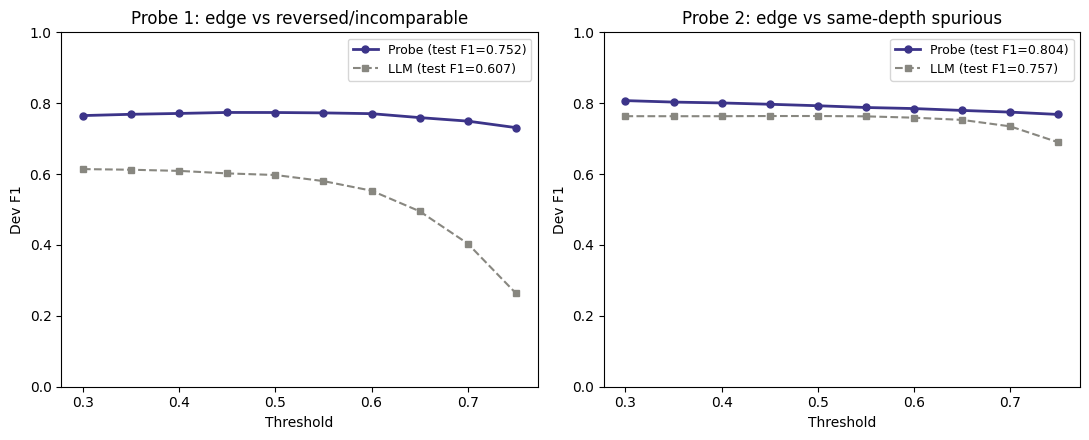

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, dev_df, res_probe, res_llm, title in [
    (axes[0], p1_dev_scored, p1_res_probe, p1_res_llm, 'Probe 1: edge vs reversed/incomparable'),
    (axes[1], p2_dev_scored, p2_res_probe, p2_res_llm, 'Probe 2: edge vs same-depth spurious')]:
    probe_f1s, llm_f1s = [], []
    for t in cfg['thresholds']:
        pp=(dev_df.probe_score>t).astype(int); lp=(dev_df.p_yes>t).astype(int)
        tp=int(((pp==1)&(dev_df.y==1)).sum()); fp=int(((pp==1)&(dev_df.y==0)).sum())
        fn=int(((pp==0)&(dev_df.y==1)).sum())
        f1p,_,_ = edge_f1(tp,fp,fn)
        tp=int(((lp==1)&(dev_df.y==1)).sum()); fp=int(((lp==1)&(dev_df.y==0)).sum())
        fn=int(((lp==0)&(dev_df.y==1)).sum())
        f1l,_,_ = edge_f1(tp,fp,fn)
        probe_f1s.append(f1p); llm_f1s.append(f1l)
    ax.plot(cfg['thresholds'], probe_f1s, 'o-', color='#3C3489', lw=2, ms=5,
            label=f'Probe (test F1={res_probe["f1"]:.3f})')
    ax.plot(cfg['thresholds'], llm_f1s, 's--', color='#888780', lw=1.5, ms=4,
            label=f'LLM (test F1={res_llm["f1"]:.3f})')
    ax.set(xlabel='Threshold', ylabel='Dev F1', title=title)
    ax.legend(fontsize=9); ax.set_ylim(0,1)

plt.tight_layout()
plt.savefig(CONTENT/'probe_classification.png', dpi=130, bbox_inches='tight')
plt.show()


In [22]:
subtype_rows = []
for ptype, label in [('same_depth','same_depth'),('cross_branch','cross_branch')]:
    r_p = eval_subset_by_type(p2_test_scored, 'probe_score', p2_t_probe, ptype)
    r_l = eval_subset_by_type(p2_test_scored, 'p_yes',       p2_t_llm,   ptype)
    subtype_rows.append({'probe':'probe2','system':'probe','subtype':label, **r_p})
    subtype_rows.append({'probe':'probe2','system':'llm',  'subtype':label, **r_l})

results = pd.DataFrame([
    {'probe':'probe1','system':'probe','subtype':'all', **p1_res_probe},
    {'probe':'probe1','system':'llm',  'subtype':'all', **p1_res_llm},
    {'probe':'probe2','system':'probe','subtype':'combined', **p2_res_probe},
    {'probe':'probe2','system':'llm',  'subtype':'combined', **p2_res_llm},
] + subtype_rows)
results.to_csv(CONTENT/'probe_classification_results.csv', index=False)
p1_test_scored.to_csv(CONTENT/'probe1_test_scores.csv', index=False)
p2_test_scored.to_csv(CONTENT/'probe2_test_scores.csv', index=False)

print('Saved: probe_classification_results.csv  probe1_test_scores.csv  '
      'probe2_test_scores.csv  probe_classification.png')
print()
print('=== FINAL SUMMARY ===')
print(f'Probe 1 (edge vs reversed/incomparable): '
      f'Probe F1={p1_res_probe["f1"]:.4f}  LLM F1={p1_res_llm["f1"]:.4f}  '
      f'margin=+{p1_res_probe["f1"]-p1_res_llm["f1"]:.4f}')
print(f'Probe 2 (edge vs same-depth spurious):   '
      f'Probe F1={p2_res_probe["f1"]:.4f}  LLM F1={p2_res_llm["f1"]:.4f}  '
      f'margin=+{p2_res_probe["f1"]-p2_res_llm["f1"]:.4f}')


Saved: probe_classification_results.csv  probe1_test_scores.csv  probe2_test_scores.csv  probe_classification.png

=== FINAL SUMMARY ===
Probe 1 (edge vs reversed/incomparable): Probe F1=0.7520  LLM F1=0.6066  margin=+0.1454
Probe 2 (edge vs same-depth spurious):   Probe F1=0.8036  LLM F1=0.7574  margin=+0.0462


---
## Statistical tests

For each probe, compares **probe** vs **LLM** on the same held-out test pairs using:

- **McNemar's test** — correct test for paired binary classifiers on the same examples; uses
  the exact binomial variant (no continuity correction) for robustness at small off-diagonal counts
- **Cohen's κ** — inter-rater agreement between probe and LLM predictions beyond chance
- **Matthews Correlation Coefficient (MCC)** — single balanced metric; reported for both
  probe and LLM; difference ΔMCC is the primary effect-size measure
- **Cohen's h** — effect size for the specificity difference (two proportions); |h|≥0.2 small,
  ≥0.5 medium, ≥0.8 large
- **Bootstrap 95% CI on F1** — 2000 resamples stratified at the plan level (resample plans,
  keep all pairs within each resampled plan) to avoid within-plan leakage

All tests use locked dev-set thresholds (no threshold re-optimisation on test data).


In [23]:
from scipy.stats import binomtest
from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np

# ── helpers ─────────────────────────────────────────────────────────────────

def mcnemar_exact(y_true, pred_a, pred_b):
    """McNemar exact binomial test: b = A right B wrong, c = A wrong B right."""
    b = int(((pred_a == y_true) & (pred_b != y_true)).sum())
    c = int(((pred_a != y_true) & (pred_b == y_true)).sum())
    n = b + c
    if n == 0:
        return 1.0, b, c
    result = binomtest(b, n, p=0.5, alternative='two-sided')
    return result.pvalue, b, c

def cohen_h(p1, p2):
    """Effect size for difference between two proportions."""
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

def mcc_from_counts(tp, fp, fn, tn):
    num = tp * tn - fp * fn
    den = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    return num / den if den > 0 else 0.0

def bootstrap_f1_ci(df, score_col, threshold, n_boot=2000, seed=42):
    """Plan-level bootstrap CI on F1. Resamples plans, keeps all pairs within."""
    rng = np.random.default_rng(seed)
    goals = np.array(df.goal.unique())
    f1s = []
    for _ in range(n_boot):
        sampled = rng.choice(goals, size=len(goals), replace=True)
        sub = df[df.goal.isin(sampled)]
        preds = (sub[score_col] > threshold).astype(int)
        tp = int(((preds==1)&(sub.y==1)).sum())
        fp = int(((preds==1)&(sub.y==0)).sum())
        fn = int(((preds==0)&(sub.y==1)).sum())
        f1v, _, _ = edge_f1(tp, fp, fn)
        f1s.append(f1v)
    f1s = np.array(f1s)
    return np.percentile(f1s, 2.5), np.percentile(f1s, 97.5)

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def h_label(h):
    ah = abs(h)
    if ah >= 0.8: return 'large'
    if ah >= 0.5: return 'medium'
    if ah >= 0.2: return 'small'
    return 'negligible'

def run_stats(label, df, probe_col, llm_col, t_probe, t_llm, res_probe, res_llm):
    y          = df.y.values
    pred_probe = (df[probe_col] > t_probe).astype(int).values
    pred_llm   = (df[llm_col]   > t_llm  ).astype(int).values

    # McNemar exact
    p_val, b, c = mcnemar_exact(y, pred_probe, pred_llm)

    # Cohen kappa (probe vs LLM agreement)
    kappa = cohen_kappa_score(pred_probe, pred_llm)

    # MCC
    mcc_probe = mcc_from_counts(res_probe['tp'], res_probe['fp'],
                                 res_probe['fn'], res_probe['tn'])
    mcc_llm   = mcc_from_counts(res_llm['tp'],   res_llm['fp'],
                                 res_llm['fn'],   res_llm['tn'])

    # Specificity + Cohen's h
    spec_probe = (res_probe['tn'] / (res_probe['tn'] + res_probe['fp'])
                  if (res_probe['tn'] + res_probe['fp']) > 0 else 0.0)
    spec_llm   = (res_llm['tn'] / (res_llm['tn'] + res_llm['fp'])
                  if (res_llm['tn'] + res_llm['fp']) > 0 else 0.0)
    h = cohen_h(spec_probe, spec_llm)

    # Bootstrap CIs on F1
    ci_probe_lo, ci_probe_hi = bootstrap_f1_ci(df, probe_col, t_probe)
    ci_llm_lo,   ci_llm_hi   = bootstrap_f1_ci(df, llm_col,   t_llm)

    print(f'\n=== {label} ===')
    print(f'  F1:  Probe {res_probe["f1"]:.4f}  95% CI [{ci_probe_lo:.4f}, {ci_probe_hi:.4f}]')
    print(f'       LLM   {res_llm["f1"]:.4f}  95% CI [{ci_llm_lo:.4f},  {ci_llm_hi:.4f}]')
    print(f'  MCC: Probe {mcc_probe:.4f}  |  LLM {mcc_llm:.4f}  |  DELTA {mcc_probe - mcc_llm:+.4f}')
    print(f'  Specificity: Probe {spec_probe:.4f}  |  LLM {spec_llm:.4f}')
    print(f"  Cohen's h (specificity gap): {h:.4f}  ({h_label(h)})")
    print(f'  McNemar exact: b={b}  c={c}  p={p_val:.4g}  {sig_stars(p_val)}')
    print(f"  Cohen's kappa (probe vs LLM agreement): {kappa:.4f}")

    return dict(
        label=label,
        f1_probe=res_probe['f1'], f1_probe_ci_lo=ci_probe_lo, f1_probe_ci_hi=ci_probe_hi,
        f1_llm=res_llm['f1'],     f1_llm_ci_lo=ci_llm_lo,     f1_llm_ci_hi=ci_llm_hi,
        mcc_probe=mcc_probe, mcc_llm=mcc_llm, delta_mcc=mcc_probe - mcc_llm,
        spec_probe=spec_probe, spec_llm=spec_llm, cohens_h=h,
        mcnemar_b=b, mcnemar_c=c, mcnemar_p=p_val,
        cohens_kappa=kappa,
    )

# ── run tests ────────────────────────────────────────────────────────────────
stat_rows = []

stat_rows.append(run_stats(
    'Probe 1 -- direction (all)',
    p1_test_scored, 'probe_score', 'p_yes',
    p1_t_probe, p1_t_llm,
    p1_res_probe, p1_res_llm,
))

stat_rows.append(run_stats(
    'Probe 2 -- necessity, combined',
    p2_test_scored, 'probe_score', 'p_yes',
    p2_t_probe, p2_t_llm,
    p2_res_probe, p2_res_llm,
))

for ptype, plabel in [('same_depth', 'same-depth'), ('cross_branch', 'cross-branch')]:
    # subset: edges + this spurious subtype only
    sub = p2_test_scored[p2_test_scored.pair_type.isin(['edge', ptype])].copy()
    r_p = eval_subset_by_type(p2_test_scored, 'probe_score', p2_t_probe, ptype)
    r_l = eval_subset_by_type(p2_test_scored, 'p_yes',       p2_t_llm,   ptype)
    stat_rows.append(run_stats(
        f'Probe 2 -- necessity, {plabel}',
        sub, 'probe_score', 'p_yes',
        p2_t_probe, p2_t_llm,
        r_p, r_l,
    ))

# ── save ─────────────────────────────────────────────────────────────────────
stats_df = pd.DataFrame(stat_rows)
stats_df.to_csv(CONTENT / 'probe_statistical_tests.csv', index=False)
print('\nSaved: probe_statistical_tests.csv')



=== Probe 1 -- direction (all) ===
  F1:  Probe 0.7520  95% CI [0.7476, 0.7567]
       LLM   0.6066  95% CI [0.6035,  0.6100]
  MCC: Probe 0.5377  |  LLM 0.0150  |  DELTA +0.5227
  Specificity: Probe 0.7312  |  LLM 0.0217
  Cohen's h (specificity gap): 1.7559  (large)
  McNemar exact: b=12915  c=2658  p=0  ***
  Cohen's kappa (probe vs LLM agreement): 0.0053

=== Probe 2 -- necessity, combined ===
  F1:  Probe 0.8036  95% CI [0.7956, 0.8113]
       LLM   0.7574  95% CI [0.7486,  0.7663]
  MCC: Probe 0.4878  |  LLM 0.0475  |  DELTA +0.4403
  Specificity: Probe 0.6697  |  LLM 0.0106
  Cohen's h (specificity gap): 1.7104  (large)
  McNemar exact: b=2622  c=1143  p=1.189e-131  ***
  Cohen's kappa (probe vs LLM agreement): 0.0095

=== Probe 2 -- necessity, same-depth ===
  F1:  Probe 0.8407  95% CI [0.8338, 0.8476]
       LLM   0.8170  95% CI [0.8105,  0.8240]
  MCC: Probe 0.5237  |  LLM 0.0633  |  DELTA +0.4604
  Specificity: Probe 0.7270  |  LLM 0.0141
  Cohen's h (specificity gap): 1.80